<a href="https://colab.research.google.com/github/maoyuqing50-code/Wiki-Trends-Analysis/blob/main/wiki_analysis_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wikipedia EN — Linguistic Analysis v2
### IS-618 · University of Mannheim

| Layer | Theory | Features |
|-------|---------|----------|
| **L1 — Lexical Masking** | Editors mask stance via softening | Epistemic hedges, Weasel words, Partisan attribution |
| **L2 — Conceptual Instability** | Editors compete for definitional authority | Definition density, Concept naming instability, Taxonomic inconsistency |
| **L3 — Structural Fragmentation** | Accumulated incoherence across article | MTLD, Para coherence, Para topic jump |

**Files needed:** `final_contested_en.json`, `final_stable_en.json`, `final_features_en.csv`


In [1]:
!pip install -q lexicalrichness sentence-transformers statsmodels spacy
!python -m spacy download en_core_web_sm -q
print('Done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 58.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Done


In [2]:
import json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import spacy
warnings.filterwarnings('ignore')

from collections import Counter
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.utils import resample
from lexicalrichness import LexicalRichness
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

nlp = spacy.load('en_core_web_sm')
print('Imports done')

Imports done


## 1. Load & Repair Data

In [3]:
def repair_json_array(path):
    with open(path, 'r', encoding='utf-8') as f:
        raw = f.read().strip()
    last_brace = raw.rfind('}')
    if last_brace == -1:
        print(f'ERROR: {path} too corrupted')
        return None
    repaired = raw[:last_brace+1]
    if not repaired.startswith('['):
        repaired = '[' + repaired
    repaired = repaired + ']'
    try:
        data = json.loads(repaired)
        print(f'Repaired {path} -- {len(data)} articles')
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
        return data
    except Exception as e:
        print(f'Repair failed: {e}')
        return None

def load_json_safe(path):
    try:
        with open(path, encoding='utf-8') as f:
            return json.load(f)
    except json.JSONDecodeError:
        print(f'JSON error in {path}, repairing...')
        return repair_json_array(path)

contested_raw = load_json_safe('final_contested_en.json')
stable_raw    = load_json_safe('final_stable_en.json')
df_feat       = pd.read_csv('final_features_en.csv')
feat_idx      = df_feat.set_index('title').to_dict(orient='index')

print(f'Contested : {len(contested_raw)}')
print(f'Stable    : {len(stable_raw)}')
print(f'CSV rows  : {len(df_feat)}')

Contested : 200
Stable    : 400
CSV rows  : 330


## 2. Subcategory Matching

In [4]:
MAX_WORD_TOL = 0.20
MAX_AGE_GAP  = 730
MAX_DIST     = 0.15

def get_subcategory(art):
    return art.get('topic_specific') or art.get('topic', 'other')

def match_articles_strict(contested_list, stable_list):
    used, pairs, rejected = set(), [], []
    def feats(a):
        return np.array([a.get('word_count', 0) / 10000,
                         a.get('age_days', 0) / 3650])
    stable_by_topic = {}
    for i, s in enumerate(stable_list):
        stable_by_topic.setdefault(s.get('topic','other'), []).append((i, s))
    for c in contested_list:
        broad = c.get('topic', 'other')
        sub_c = get_subcategory(c)
        candidates = stable_by_topic.get(broad, [])
        if not candidates:
            rejected.append((c['title'], 'no same-topic stable'))
            continue
        same_sub   = [(i,s) for i,s in candidates if get_subcategory(s)==sub_c and i not in used]
        same_broad = [(i,s) for i,s in candidates if get_subcategory(s)!=sub_c and i not in used]
        matched = None
        for pool in [same_sub, same_broad]:
            if matched or not pool: continue
            pf = np.array([feats(s) for _,s in pool])
            nn = NearestNeighbors(n_neighbors=min(10,len(pool)), metric='euclidean')
            nn.fit(pf)
            dists, idxs = nn.kneighbors(feats(c).reshape(1,-1))
            for dist, idx in zip(dists[0], idxs[0]):
                if dist > MAX_DIST: break
                orig_i, s = pool[idx]
                if orig_i in used: continue
                age_gap  = abs(c.get('age_days',0) - s.get('age_days',0))
                wc_ratio = abs(c.get('word_count',1) - s.get('word_count',1)) / max(c.get('word_count',1),1)
                if age_gap > MAX_AGE_GAP or wc_ratio > MAX_WORD_TOL: continue
                matched = (orig_i, s, dist, get_subcategory(s)==sub_c)
                break
        if matched:
            orig_i, s, dist, same_sub_flag = matched
            used.add(orig_i)
            pairs.append({'contested':c, 'stable':s, 'dist':dist, 'same_subcat':same_sub_flag})
        else:
            rejected.append((c['title'], 'no valid match'))
    return pairs, rejected

pairs, rejected = match_articles_strict(contested_raw, stable_raw)
same_sub = sum(1 for p in pairs if p['same_subcat'])
print(f'Matched : {len(pairs)} pairs')
print(f'Same subcat : {same_sub}/{len(pairs)}')
print(f'Rejected : {len(rejected)}')

Matched : 128 pairs
Same subcat : 37/128
Rejected : 72


## 3. Feature Functions

In [14]:
# ── Text preprocessing ────────────────────────────────────────────────────────
def split_into_paragraphs(text, sentences_per_para=5):
    if not text: return []
    infobox_end = text.rfind('}}')
    if infobox_end != -1:
        text = text[infobox_end+2:].strip()
    text = re.sub(r'\[\[.*?\]\]', '', text)
    text = re.sub(r"'{2,}", '', text)
    sentences = re.split(r'(?<=[.!?])\s+', text)
    sentences = [s.strip() for s in sentences
                 if len(s.split()) >= 5 and s.strip() and s.strip()[0].isupper()]
    if len(sentences) < 2: return []
    paras = []
    for i in range(0, len(sentences), sentences_per_para):
        group = ' '.join(sentences[i:i+sentences_per_para])
        if len(group.split()) >= 20:
            paras.append(group)
    return paras

WEASEL_WORDS = [
    'some people','many people','most people','experts say','it is said',
    'it is believed','it has been suggested','it is often said',
    'it is claimed','it is argued','researchers say','scientists say',
    'historians say','critics say','studies show','research shows',
    'many','most','several','a number of','numerous','various','certain',
    'importantly','interestingly','notably','significantly',
    'of course','naturally','obviously','clearly','undoubtedly',
]

def weasel_density(text):
    if not text or not text.strip(): return 0.0
    n = max(len(text.split()), 1)
    t = text.lower()
    count = sum(t.count(w) for w in WEASEL_WORDS)
    return round(count / n * 1000, 4)

# ── Layer 2: Concept naming instability ──────────────────────────────────────
def concept_naming_instability(text, title):
    if not text or not title: return 0.0
    title_doc = nlp(title.lower())
    title_kw = {t.lemma_ for t in title_doc if not t.is_stop and t.is_alpha and len(t) > 2}
    if not title_kw: return 0.0
    doc = nlp(text[:3000])
    candidates = []
    for chunk in doc.noun_chunks:
        chunk_lemmas = {t.lemma_.lower() for t in chunk if not t.is_stop and t.is_alpha}
        if chunk_lemmas & title_kw:
            label = ' '.join(t.lemma_.lower() for t in chunk if not t.is_stop and t.is_alpha)
            if label: candidates.append(label)
    if not candidates: return 0.0
    counts = Counter(candidates)
    return len(counts) / sum(counts.values())

# ── Layer 2: Taxonomic inconsistency ─────────────────────────────────────────
CATEGORY_NOUNS = {
    'war','conflict','battle','campaign','operation','massacre','genocide',
    'incident','crisis','dispute','movement','protest','revolt','uprising',
    'attack','raid','siege','occupation','invasion',
    'organization','organisation','group','party','government','institution',
    'body','agency','association','company','firm','coalition','alliance',
    'theory','concept','phenomenon','ideology','doctrine','policy','practice',
    'system','approach','method','tradition','culture',
    'politician','leader','activist','official','figure','author','writer',
    'scientist','researcher','journalist','artist','athlete',
    'region','territory','area','zone','country','state','province','city',
}
COPULA_PAT = re.compile(r'\b(?:is|was|are|were|became?)\s+(?:a|an|the)?\s*([a-z\-]+)', re.IGNORECASE)

def taxonomic_inconsistency(text):
    if not text: return 0.0
    found = []
    for m in COPULA_PAT.finditer(text[:3000]):
        c = m.group(1).lower().rstrip('s')
        if c in CATEGORY_NOUNS or c+'s' in CATEGORY_NOUNS:
            found.append(c)
    if not found: return 0.0
    return len(set(found)) / len(found)

# ── Layer 3: MTLD ─────────────────────────────────────────────────────────────
def compute_mtld(text):
    if not text or len(text.split()) < 50: return np.nan
    try:
        return round(LexicalRichness(text).mtld(threshold=0.72), 4)
    except:
        return np.nan

print('Feature functions defined')
print('Loading sentence transformer...')
st_model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
print('Model loaded')

# ── Layer 3: Para coherence ───────────────────────────────────────────────────
def para_coherence(text):
    paras = split_into_paragraphs(text)
    if len(paras) < 2: return np.nan
    try:
        embs = st_model.encode(paras, show_progress_bar=False)
        dists = [1 - cosine_similarity([embs[i]], [embs[i+1]])[0][0] for i in range(len(embs)-1)]
        return round(np.mean(dists), 4)
    except:
        return np.nan

# ── Layer 3: Paragraph topic jump ────────────────────────────────────────────
def paragraph_topic_jump(text):
    paras = split_into_paragraphs(text)
    if len(paras) < 2: return np.nan
    first_sents = []
    for p in paras:
        sents = re.split(r'(?<=[.!?])\s+', p)
        if sents: first_sents.append(sents[0])
    if len(first_sents) < 2: return np.nan
    try:
        embs = st_model.encode(first_sents, show_progress_bar=False)
        dists = [1 - cosine_similarity([embs[i]], [embs[i+1]])[0][0] for i in range(len(embs)-1)]
        return round(np.mean(dists), 4)
    except:
        return np.nan

print('All feature functions ready')

Feature functions defined
Loading sentence transformer...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded
All feature functions ready


## 4. Build Feature Matrix (~20-30 min)

In [25]:
LING_FEATURES = [
    'hedging_density', 'weasel_density', 'partisan_density',
    'def_ratio', 'concept_naming_instab', 'taxonomic_inconsistency',
    'mtld', 'para_coherence', 'para_topic_jump',
]

LABELS = {
    'hedging_density'         : 'Epistemic hedges',
    'weasel_density'          : 'Weasel words',
    'partisan_density'        : 'Partisan attribution',
    'def_ratio'               : 'Definition density',
    'concept_naming_instab'   : 'Concept naming instability',
    'taxonomic_inconsistency' : 'Taxonomic inconsistency',
    'mtld'                    : 'Lexical diversity (MTLD)',
    'para_coherence'          : 'Para coherence',
    'para_topic_jump'         : 'Para topic jump',
}

LAYER_MAP = {
    'hedging_density':'L1', 'weasel_density':'L1', 'partisan_density':'L1',
    'def_ratio':'L2', 'concept_naming_instab':'L2', 'taxonomic_inconsistency':'L2',
    'mtld':'L3', 'para_coherence':'L3', 'para_topic_jump':'L3',
}

records = []
total = len(pairs) * 2
done  = 0
print(f'Extracting features for {len(pairs)} pairs ({total} articles)...')

for p in pairs:
    for role, art in [('contested', p['contested']), ('stable', p['stable'])]:
        title = art['title']
        text  = art.get('clean_text', '')
        ex    = feat_idx.get(title, {})
        records.append({
            'title'                  : title,
            'label'                  : 0 if role == 'contested' else 1,
            'label_name'             : role,
            'topic'                  : art.get('topic', 'other'),
            'word_count'             : art.get('word_count', 0),
            'age_days'               : art.get('age_days', 0),
            'hedging_density'        : ex.get('hedging_density', np.nan),
            'weasel_density'         : weasel_density(text),
            'partisan_density'       : ex.get('partisan_density', np.nan),
            'def_ratio'              : ex.get('def_ratio', np.nan),
            'concept_naming_instab'  : concept_naming_instability(text, title),
            'taxonomic_inconsistency': taxonomic_inconsistency(text),
            'mtld'                   : compute_mtld(text),
            'para_coherence'         : para_coherence(text),
            'para_topic_jump'        : paragraph_topic_jump(text),
        })
        done += 1
        if done % 20 == 0:
            print(f'  {done}/{total} done...')

df = pd.DataFrame(records)
df.to_csv('features_v2.csv', index=False)
print(f'Done. Shape: {df.shape}')
print(f'NaN counts:')
print(df[LING_FEATURES].isna().sum())

Extracting features for 128 pairs (256 articles)...
  20/256 done...
  40/256 done...
  60/256 done...
  80/256 done...
  100/256 done...
  120/256 done...
  140/256 done...
  160/256 done...
  180/256 done...
  200/256 done...
  220/256 done...
  240/256 done...
Done. Shape: (256, 15)
NaN counts:
hedging_density            18
weasel_density              0
partisan_density           18
def_ratio                  18
concept_naming_instab       0
taxonomic_inconsistency     0
mtld                        0
para_coherence             45
para_topic_jump            45
dtype: int64


## 5. Direction Check

In [28]:
# All features predicted Contested > Stable
c_df = df[df.label == 0]
s_df = df[df.label == 1]

print(f'{"Feature":<30} {"Contested":>10} {"Stable":>10} {"Diff%":>8}  Dir  Layer')
print('-' * 70)
n_correct = 0
for f in LING_FEATURES:
    cm = c_df[f].mean()
    sm = s_df[f].mean()
    if np.isnan(cm) or np.isnan(sm):
        print(f'{LABELS[f]:<30} {"NaN":>10} {"NaN":>10} {"---":>8}  ?    {LAYER_MAP[f]}')
        continue
    diff = (cm - sm) / (abs(sm) + 1e-9) * 100
    ok = 'V' if cm > sm else 'X'
    if cm > sm: n_correct += 1
    print(f'{LABELS[f]:<30} {cm:>10.4f} {sm:>10.4f} {diff:>+8.1f}%  {ok}    {LAYER_MAP[f]}')
print(f'\nDirection correct: {n_correct}/9')

Feature                         Contested     Stable    Diff%  Dir  Layer
----------------------------------------------------------------------
Epistemic hedges                   0.9083     0.2753   +229.9%  V    L1
Weasel words                       4.1066     2.9714    +38.2%  V    L1
Partisan attribution               0.0221     0.0000 +2206190476.2%  V    L1
Definition density                 0.0542     0.0404    +34.2%  V    L2
Concept naming instability         0.5729     0.5445     +5.2%  V    L2
Taxonomic inconsistency            0.1211     0.0859    +40.9%  V    L2
Lexical diversity (MTLD)          75.4128    66.1377    +14.0%  V    L3
Para coherence                     0.4094     0.4185     -2.2%  X    L3
Para topic jump                    0.6392     0.6736     -5.1%  X    L3

Direction correct: 7/9


## 6. Wilcoxon Tests (Holm corrected)

In [29]:
diff_records = []
for p in pairs:
    c_row = df[df.title == p['contested']['title']]
    s_row = df[df.title == p['stable']['title']]
    if c_row.empty or s_row.empty: continue
    rec = {f: c_row.iloc[0][f] - s_row.iloc[0][f] for f in LING_FEATURES}
    diff_records.append(rec)
diff_df = pd.DataFrame(diff_records)
print(f'Valid pairs: {len(diff_df)}')

raw_results = []
for f in LING_FEATURES:
    vals = diff_df[f].dropna()
    if len(vals) < 5: continue
    _, p_val = wilcoxon(vals)
    raw_results.append({'feature': f, 'mean_diff': vals.mean(),
                        'pct_c_hi': (vals > 0).mean() * 100, 'p_raw': p_val, 'n': len(vals)})

_, p_holm, _, _ = multipletests([r['p_raw'] for r in raw_results], method='holm')
for r, p_h in zip(raw_results, p_holm):
    r['p_holm'] = p_h
    r['sig'] = '***' if p_h<0.001 else ('**' if p_h<0.01 else ('*' if p_h<0.05 else ('~' if p_h<0.10 else 'ns')))

print(f'{"Feature":<30} {"Mean d":>8} {"C>S%":>7} {"p(Holm)":>10}  Sig   Layer')
print('-' * 68)
for r in raw_results:
    f = r['feature']
    print(f'{LABELS[f]:<30} {r["mean_diff"]:>+8.4f} {r["pct_c_hi"]:>6.1f}% {r["p_holm"]:>10.4f}  {r["sig"]:<5} {LAYER_MAP[f]}')
print(f'\nSignificant: {sum(1 for r in raw_results if r["p_holm"]<0.05)}/{len(raw_results)}')

Valid pairs: 128
Feature                          Mean d    C>S%    p(Holm)  Sig   Layer
--------------------------------------------------------------------
Epistemic hedges                +0.6180   50.9%     0.0000  ***   L1
Weasel words                    +1.1352   61.7%     0.0010  ***   L1
Partisan attribution            +0.0085    2.7%     0.4352  ns    L1
Definition density              +0.0119   60.9%     0.1244  ns    L2
Concept naming instability      +0.0284   53.9%     0.9540  ns    L2
Taxonomic inconsistency         +0.0352   11.7%     0.9540  ns    L2
Lexical diversity (MTLD)        +9.2751   64.1%     0.0008  ***   L3
Para coherence                  -0.0045   50.6%     0.9540  ns    L3
Para topic jump                 -0.0277   38.8%     0.3113  ns    L3

Significant: 3/9


## 7. Logistic Regression — Layer Comparison

In [30]:
df_topic  = pd.get_dummies(df['topic'], prefix='topic', drop_first=True)
df_model  = pd.concat([df.reset_index(drop=True), df_topic.reset_index(drop=True)], axis=1)
topic_cols = list(df_topic.columns)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

L1 = ['hedging_density', 'weasel_density', 'partisan_density']
L2 = ['def_ratio', 'concept_naming_instab', 'taxonomic_inconsistency']
L3 = ['mtld', 'para_coherence', 'para_topic_jump']

feature_sets = {
    'L1 only (Lexical Masking)'          : L1,
    'L2 only (Conceptual Instability)'   : L2,
    'L3 only (Structural Fragmentation)' : L3,
    'L1 + L2'                            : L1 + L2,
    'All 9 linguistic'                   : L1 + L2 + L3,
    'All 9 + topic controls'             : L1 + L2 + L3 + topic_cols,
}

print(f'{"Feature set":<42} {"F1":>8} {"Acc":>8} {"vs base":>10}')
print('-' * 72)
base = max(df.label.mean(), 1-df.label.mean())
results = {}
for name, feats in feature_sets.items():
    avail = [f for f in feats if f in df_model.columns]
    d = df_model[avail + ['label']].dropna()
    if len(d) < 20 or not avail: continue
    X = StandardScaler().fit_transform(d[avail].values)
    y = d['label'].values
    f1s  = cross_val_score(lr, X, y, cv=cv, scoring='f1_macro')
    accs = cross_val_score(lr, X, y, cv=cv, scoring='accuracy')
    results[name] = {'f1': f1s.mean(), 'acc': accs.mean()}
    print(f'{name:<42} {f1s.mean():>8.3f} {accs.mean():>8.3f} {accs.mean()-base:>+10.3f}')
print(f'\nBaseline: {base:.3f}')

Feature set                                      F1      Acc    vs base
------------------------------------------------------------------------
L1 only (Lexical Masking)                     0.709    0.710     +0.210
L2 only (Conceptual Instability)              0.586    0.589     +0.089
L3 only (Structural Fragmentation)            0.590    0.593     +0.093
L1 + L2                                       0.672    0.672     +0.172
All 9 linguistic                              0.676    0.678     +0.178
All 9 + topic controls                        0.720    0.723     +0.223

Baseline: 0.500


## 8. Bootstrap 95% CI (1,000 resamples)

In [31]:
all_feats = [f for f in L1+L2+L3 if f in df_model.columns] + topic_cols
d_full    = df_model[all_feats + ['label']].dropna()
X_full    = StandardScaler().fit_transform(d_full[all_feats].values)
y_full    = d_full['label'].values
lr.fit(X_full, y_full)

coef_boot = []
for _ in range(1000):
    X_b, y_b = resample(X_full, y_full)
    if len(set(y_b)) < 2: continue
    m = LogisticRegression(class_weight='balanced', max_iter=1000)
    m.fit(X_b, y_b)
    coef_boot.append(m.coef_[0])
coef_arr = np.array(coef_boot)
ling_idx  = [i for i,f in enumerate(all_feats) if f in L1+L2+L3]

print(f'{"Feature":<30} {"Coef":>8} {"95% CI":>22}  Stable?  Layer')
print('-' * 75)
for i in ling_idx:
    f  = all_feats[i]
    lo = np.percentile(coef_arr[:,i], 2.5)
    hi = np.percentile(coef_arr[:,i], 97.5)
    c  = lr.coef_[0][i]
    ok = 'YES' if (lo>0 or hi<0) else 'unstable'
    print(f'{LABELS.get(f,f):<30} {c:>+8.3f} [{lo:>+7.3f}, {hi:>+7.3f}]  {ok:<9} {LAYER_MAP.get(f,"")}')

Feature                            Coef                 95% CI  Stable?  Layer
---------------------------------------------------------------------------
Epistemic hedges                 -1.038 [ -1.854,  -0.619]  YES       L1
Weasel words                     -0.388 [ -0.785,  -0.033]  YES       L1
Partisan attribution             -0.607 [ -0.956,  -0.113]  YES       L1
Definition density               -0.264 [ -0.677,  +0.074]  unstable  L2
Concept naming instability       -0.043 [ -0.409,  +0.359]  unstable  L2
Taxonomic inconsistency          -0.026 [ -0.437,  +0.361]  unstable  L2
Lexical diversity (MTLD)         -0.352 [ -0.737,  -0.042]  YES       L3
Para coherence                   -0.248 [ -0.675,  +0.148]  unstable  L3
Para topic jump                  +0.606 [ +0.208,  +1.139]  YES       L3


## 9. Visualisations

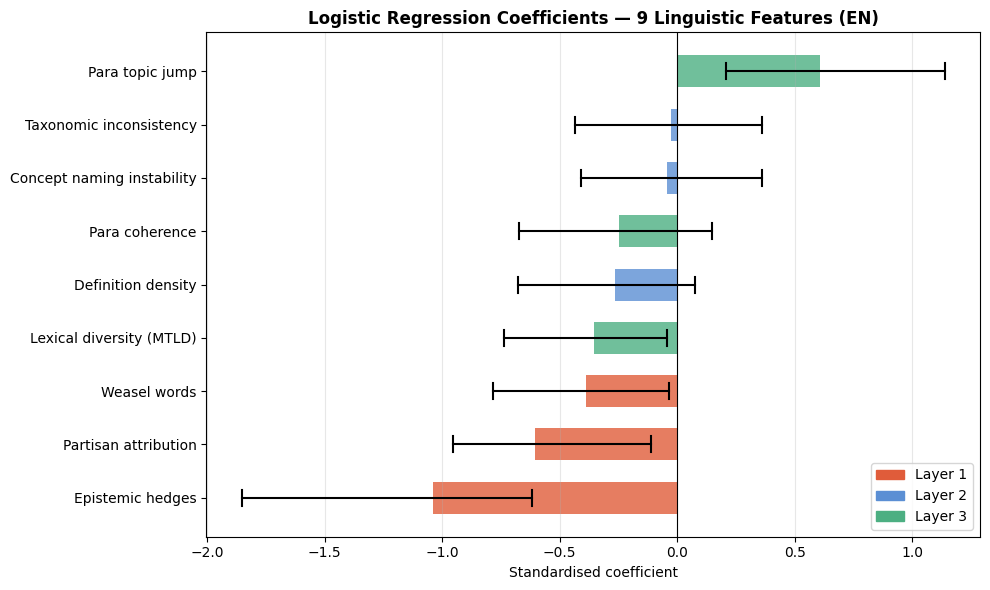

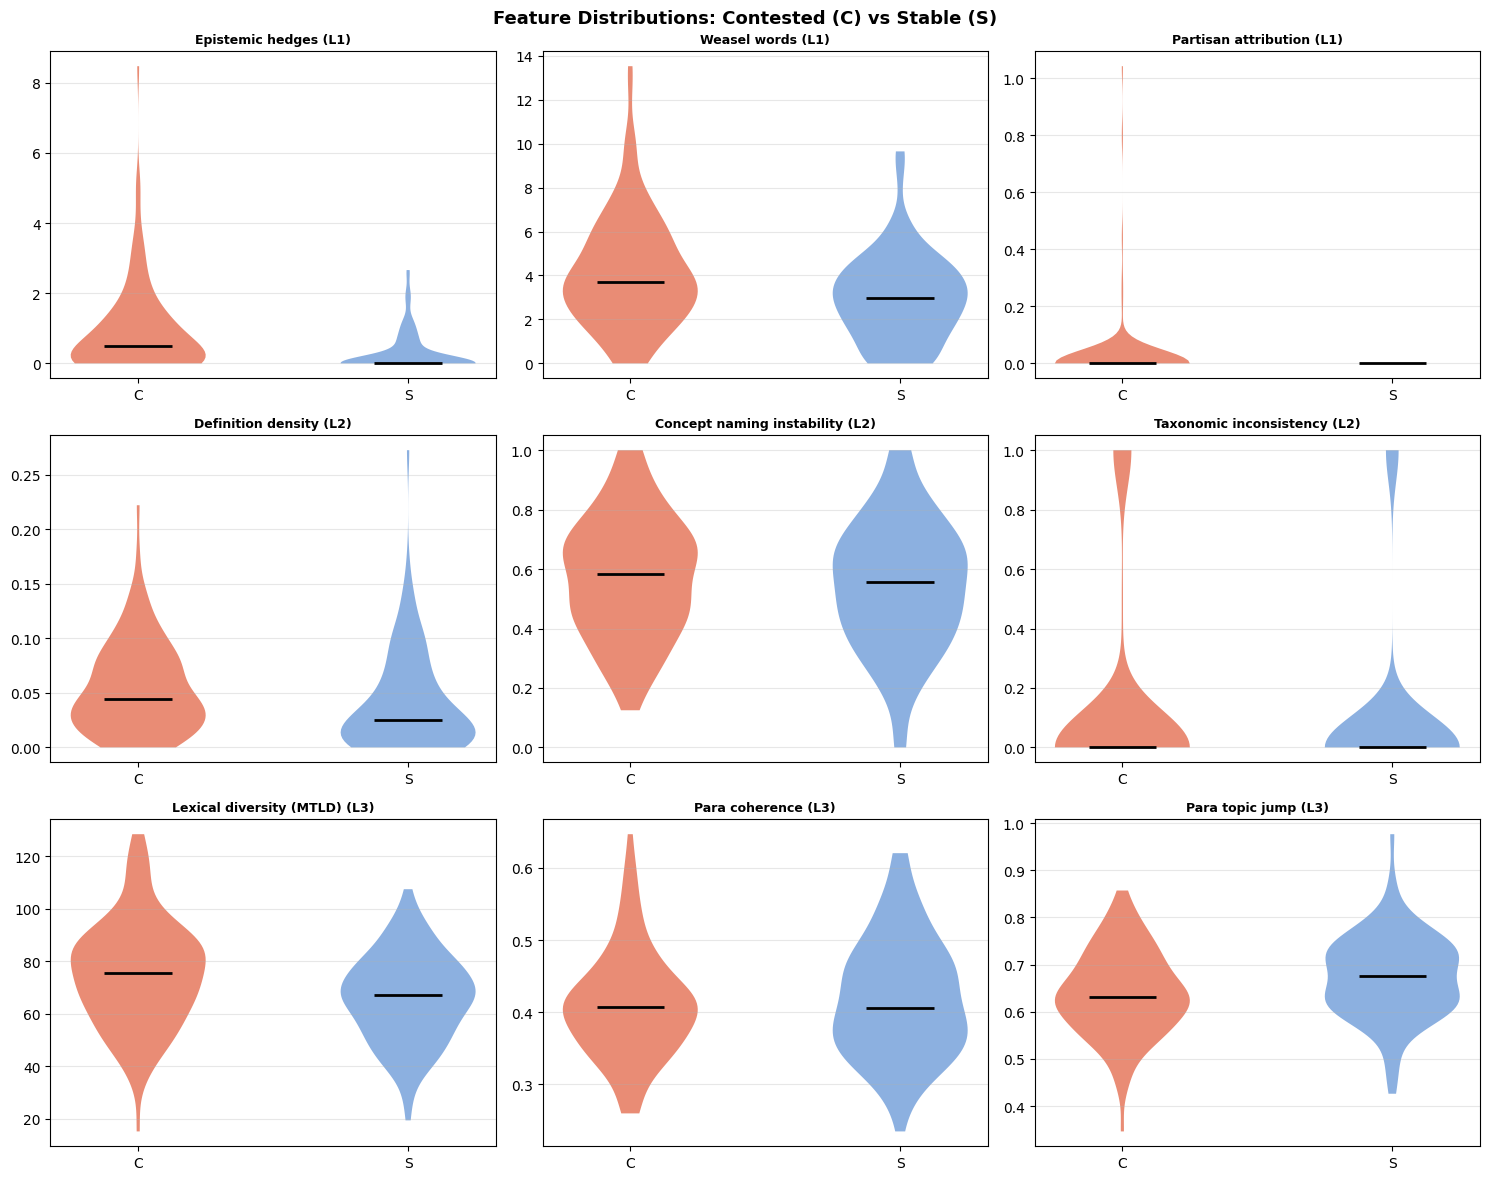

In [32]:
LAYER_COLORS = {'L1':'#E05C3A', 'L2':'#5B8FD4', 'L3':'#4CAF82'}

# Coefficient plot
coef_data = []
for i in ling_idx:
    f = all_feats[i]
    coef_data.append({
        'label': LABELS[f],
        'coef' : lr.coef_[0][i],
        'lo'   : np.percentile(coef_arr[:,i], 2.5),
        'hi'   : np.percentile(coef_arr[:,i], 97.5),
        'layer': LAYER_MAP[f]
    })
coef_data.sort(key=lambda x: x['coef'])

fig, ax = plt.subplots(figsize=(10,6))
for j, d in enumerate(coef_data):
    color = LAYER_COLORS[d['layer']]
    ax.barh(j, d['coef'], color=color, alpha=0.8, height=0.6)
    ax.plot([d['lo'],d['hi']], [j,j], color='black', linewidth=1.5)
    ax.plot([d['lo'],d['lo']], [j-0.15,j+0.15], color='black', linewidth=1.5)
    ax.plot([d['hi'],d['hi']], [j-0.15,j+0.15], color='black', linewidth=1.5)
ax.set_yticks(range(len(coef_data)))
ax.set_yticklabels([d['label'] for d in coef_data], fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised coefficient', fontsize=10)
ax.set_title('Logistic Regression Coefficients — 9 Linguistic Features (EN)', fontsize=12, fontweight='bold')
patches = [mpatches.Patch(color=c, label=f'Layer {l[-1]}') for l,c in LAYER_COLORS.items()]
ax.legend(handles=patches, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('coefficients_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Violin plots
fig, axes = plt.subplots(3, 3, figsize=(15,12))
axes = axes.flatten()
for ax, f in zip(axes, LING_FEATURES):
    c_vals = df[df.label==0][f].dropna().values
    s_vals = df[df.label==1][f].dropna().values
    if len(c_vals) < 2 or len(s_vals) < 2:
        ax.set_title(f'{LABELS[f]} (no data)', fontsize=8)
        continue
    parts = ax.violinplot([c_vals, s_vals], positions=[0,1], showmedians=True, showextrema=False)
    for body, color in zip(parts['bodies'], ['#E05C3A','#5B8FD4']):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    ax.set_xticks([0,1])
    ax.set_xticklabels(['C','S'], fontsize=10)
    ax.set_title(f'{LABELS[f]} ({LAYER_MAP[f]})', fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Feature Distributions: Contested (C) vs Stable (S)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions_v2.png', dpi=150, bbox_inches='tight')
plt.show()